# Vascular skin lesions with Ray AI Runtime (AIR)

## Notebook overview

This notebook builds a vascular lesion classifier using Ray AIR:
- Ray Data for parallel image loading and feature extraction.
- Ray Train for SVM training in a reproducible pipeline.
- Ray Tune for lightweight hyperparameter search.

The dataset is small, so image size and tuning budget are kept modest.

## Ray runtime (local vs docker)
If you start the Ray cluster via `deploy/docker-compose.yaml`, the head node exposes port `10001` for Ray client connections.
Set `RAY_ADDRESS` to connect (host machine: `ray://localhost:10001`, container in the same compose network: `ray://ray-head:10001`).
If `RAY_ADDRESS` is unset, this notebook starts a local Ray runtime.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
from dotenv import load_dotenv

import ray
from ray import tune
from ray.tune.tuner import Tuner, TuneConfig

import joblib
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
 )
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler as SkMinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.base import clone

%matplotlib inline

load_dotenv()

RANDOM_STATE = 42
DATA_DIR = Path("vascular_skin_lesion")
IMG_SIZE = (128, 128)

In [2]:
def summarize_classification(y_true, y_pred, labels):
    print(classification_report(y_true=y_true, y_pred=y_pred, target_names=labels))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.xticks(rotation=45)
    plt.show()

## Baseline SVM (single-thread, raw pixels)
We start with a deliberately simple raw-pixel SVM baseline. This is useful as a sanity check, but it is not directly comparable to the stronger engineered-feature SVM in `classify_skin_cancer_base.ipynb`. The comparable classical baseline is evaluated after feature extraction.

### Simple SVM with test-train split

In [3]:
records_raw = []
for cls_dir in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
    cls = cls_dir.name
    for img_path in cls_dir.glob("*"):
        try:
            with Image.open(img_path) as im:
                w, h = im.size
        except Exception:
            continue
        records_raw.append({"path": str(img_path), "label": cls, "width": w, "height": h})

if not records_raw:
    raise ValueError(f"No images found under {DATA_DIR.resolve()}")

df = pd.DataFrame(records_raw)
label_names = sorted(df["label"].unique())
label_to_id = {name: idx for idx, name in enumerate(label_names)}
df["label_id"] = df["label"].map(label_to_id)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}

In [4]:
df.head(5)

,path,label,width,height,label_id
0,vascular_skin_lesion/nv/ISIC_0024384.jpg,nv,600,450,0
1,vascular_skin_lesion/nv/ISIC_0024429.jpg,nv,600,450,0
2,vascular_skin_lesion/nv/ISIC_0024353.jpg,nv,600,450,0
3,vascular_skin_lesion/nv/ISIC_0024378.jpg,nv,600,450,0
4,vascular_skin_lesion/nv/ISIC_0024328.jpg,nv,600,450,0


In [5]:
print("Total images:", len(df))
print("Class map:", label_to_id)

Total images: 284
Class map: {'nv': 0, 'vasc': 1}


Class counts:
label
nv      142
vasc    142
Name: count, dtype: int64


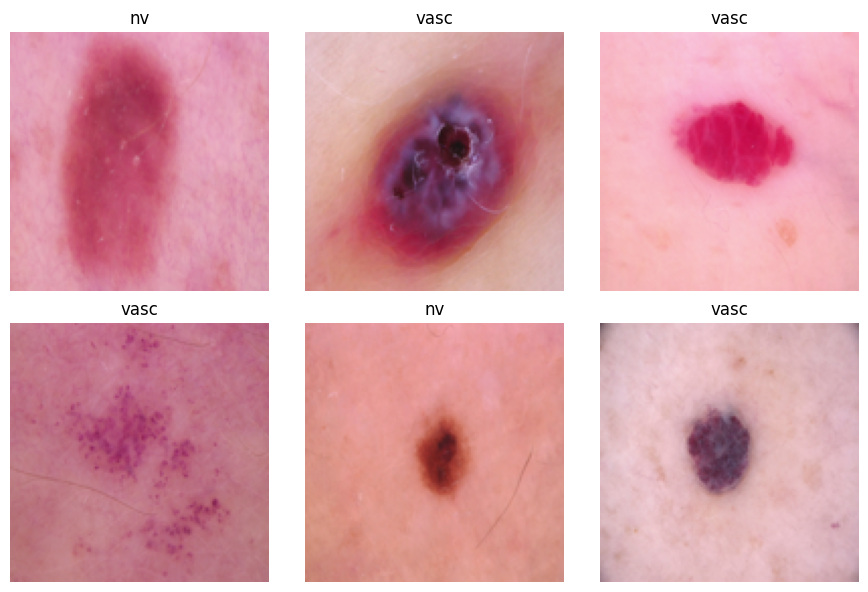

In [6]:
sample = df.sample(min(6, len(df)), random_state=RANDOM_STATE)
cols = 3
rows = int(np.ceil(len(sample) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax in axes[len(sample):]:
    ax.axis("off")

for i, (_, r) in enumerate(sample.iterrows()):
    img = Image.open(r["path"]).convert("RGB")
    ax = axes[i]
    ax.imshow(img.resize(IMG_SIZE))
    ax.set_title(r["label"])
    ax.axis("off")

print("Class counts:")
print(df["label"].value_counts().reindex(label_names))

plt.tight_layout()

In [7]:
def summarize_cv(cv_results, model_name):
    summary = {"model": model_name}
    for metric in SCORING.keys():
        values = cv_results[f"test_{metric}"]
        summary[f"{metric}_mean"] = float(np.mean(values))
        summary[f"{metric}_std"] = float(np.std(values))
    return pd.DataFrame([summary])

def run_cv(model, X, y, model_name, cv, use_ray=False, n_jobs=None):
    params = {
        "estimator": model,
        "X": X,
        "y": y,
        "cv": cv,
        "scoring": SCORING,
        "n_jobs": n_jobs,
        "error_score": "raise",
    }

    if n_jobs is None:
        n_jobs = -1 if use_ray else 1
    if use_ray:
        with joblib.parallel_backend("ray"):
            results = cross_validate(**params)
    else:
        results = cross_validate(**params)

    summary = summarize_cv(results, model_name)
    return results, summary

def cv_classification_report(model, X, y, cv):
    preds = cross_val_predict(model, X, y, cv=cv, n_jobs=1)
    summarize_classification(y_true=y, y_pred=preds, labels=label_names)

In [8]:
# Single-thread SVM baseline on raw pixels
BASELINE_IMG_SIZE = (64, 64)

def load_image_array(path, size=BASELINE_IMG_SIZE):
    with Image.open(path) as im:
        im = im.convert("RGB").resize(size)
        arr = np.array(im).astype(np.float32) / 255.0
    return arr

In [9]:
X_raw = np.stack([load_image_array(p) for p in df["path"]])
y_raw = df["label_id"].values
X_raw_flat = X_raw.reshape((X_raw.shape[0], -1))

In [10]:
X_raw_train_flat, X_raw_test_flat, y_raw_train, y_raw_test = train_test_split(
    X_raw_flat, y_raw, test_size=0.2, stratify=y_raw, random_state=RANDOM_STATE
)

In [11]:
simple_svm = SVC(kernel="rbf", random_state=RANDOM_STATE)
simple_svm.fit(X_raw_train_flat, y_raw_train);

Raw-pixel SVM report (test data):


              precision    recall  f1-score   support

          nv       0.96      0.86      0.91        29
        vasc       0.87      0.96      0.92        28

    accuracy                           0.91        57
   macro avg       0.92      0.91      0.91        57
weighted avg       0.92      0.91      0.91        57



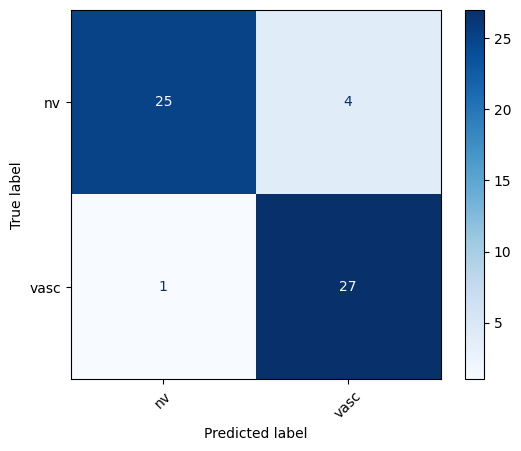

In [12]:
print("Raw-pixel SVM report (test data):")
summarize_classification(y_true=y_raw_test, y_pred=simple_svm.predict(X_raw_test_flat), labels=label_names)

Raw-pixel SVM report (full dataset):
              precision    recall  f1-score   support

          nv       0.96      0.82      0.89       142
        vasc       0.85      0.96      0.90       142

    accuracy                           0.89       284
   macro avg       0.90      0.89      0.89       284
weighted avg       0.90      0.89      0.89       284



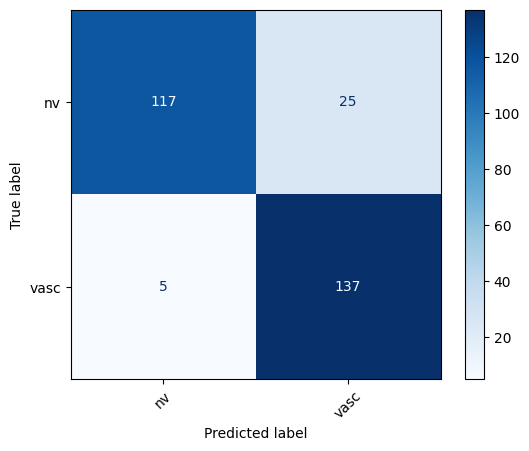

In [13]:
print("Raw-pixel SVM report (full dataset):")
summarize_classification(y_true=y_raw, y_pred=simple_svm.predict(X_raw_flat), labels=label_names)

The classifier performs pretty well, achiving around 0.96 macro recall score both on the test and the full dataset. We have used `rbf` kernel, which is the most universal kernel, because it can handle non-linear features. 

### Simple SVM with cross-validation and hyperparameter tuning

Let's check if the good performance will be present with simple SVM with cross-validation. Cross validation is a recommended approach for small datasets, as it allows to use all data for training and testing. We will use 5-fold cross-validation, which is a common choice for small datasets.

In [14]:
baseline_model = Pipeline(
    [
        ("scaler", SkMinMaxScaler(feature_range=(-1, 1))),
        ("svc", SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)

In [21]:
simple_svm_grid_params = {
    "svc__kernel": ["linear", "rbf"],
    "svc__C": [0.1, 1, 10, 100, 1000],
    "svc__gamma": [1, 0.1, 0.01, 0.001, 0.0001],
}

In [16]:
svm_grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=simple_svm_grid_params,
    cv=cv,
    scoring="recall_macro",
    n_jobs=-1,
    error_score="raise",
)
svm_grid_search.fit(X_raw_train_flat, y_raw_train);

In [17]:
simple_svm_best_model = svm_grid_search.best_estimator_

Raw-pixel SVM report (test data):
              precision    recall  f1-score   support

          nv       0.97      1.00      0.98        29
        vasc       1.00      0.96      0.98        28

    accuracy                           0.98        57
   macro avg       0.98      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



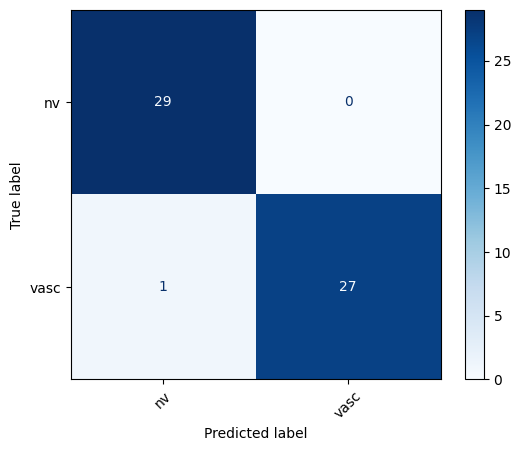

In [18]:
print("Raw-pixel SVM report (test data):")
summarize_classification(y_true=y_raw_test, y_pred=simple_svm_best_model.predict(X_raw_test_flat), labels=label_names)

Raw-pixel SVM report (full data):
              precision    recall  f1-score   support

          nv       0.99      1.00      1.00       142
        vasc       1.00      0.99      1.00       142

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284



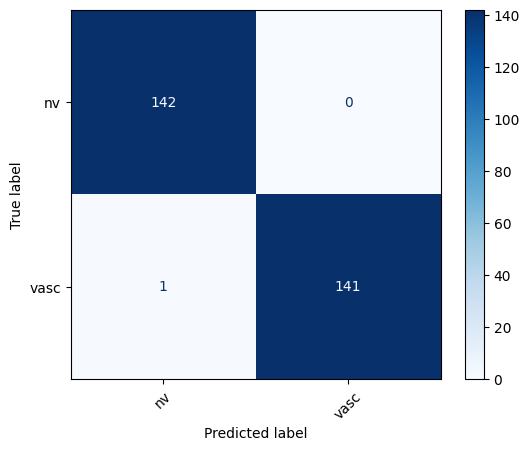

In [19]:
print("Raw-pixel SVM report (full data):")
summarize_classification(y_true=y_raw, y_pred=simple_svm_best_model.predict(X_raw_flat), labels=label_names)

In [20]:
simple_svm_best_model.get_params()

{'memory': None,
 'steps': [('scaler', MinMaxScaler(feature_range=(-1, 1))),
  ('svc',
   SVC(C=0.1, class_weight='balanced', gamma=1, kernel='linear', random_state=42))],
 'transform_input': None,
 'verbose': False,
 'scaler': MinMaxScaler(feature_range=(-1, 1)),
 'svc': SVC(C=0.1, class_weight='balanced', gamma=1, kernel='linear', random_state=42),
 'scaler__clip': False,
 'scaler__copy': True,
 'scaler__feature_range': (-1, 1),
 'svc__C': 0.1,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': 'balanced',
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 1,
 'svc__kernel': 'linear',
 'svc__max_iter': -1,
 'svc__probability': False,
 'svc__random_state': 42,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

After tuning, we can see that the best hyperparameters are `C=0.1` and `kernel=linear`. The classifier performs much better than we could expect. This is likely due to the small dataset size which contains only 242 images. Neverthless it is pretty unexpected that the data is almost perfectly linearly separable in the raw pixel space.

### SVM with sklearn cross_validation

              precision    recall  f1-score   support

          nv       0.83      0.86      0.85        29
        vasc       0.85      0.82      0.84        28

    accuracy                           0.84        57
   macro avg       0.84      0.84      0.84        57
weighted avg       0.84      0.84      0.84        57



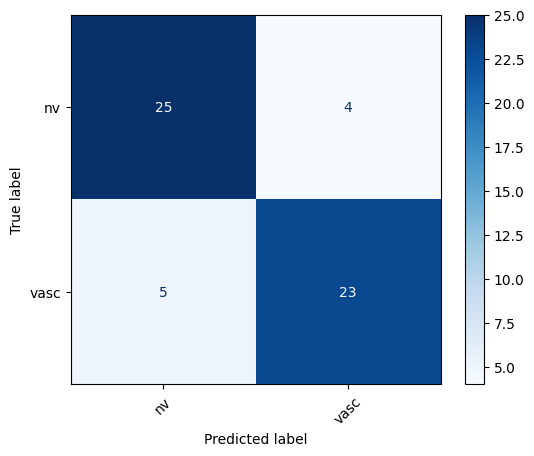

In [21]:
cv_classification_report(svm_grid_search, X_raw_test_flat, y_raw_test, cv=cv)

              precision    recall  f1-score   support

          nv       0.92      0.91      0.91       142
        vasc       0.91      0.92      0.92       142

    accuracy                           0.92       284
   macro avg       0.92      0.92      0.92       284
weighted avg       0.92      0.92      0.92       284



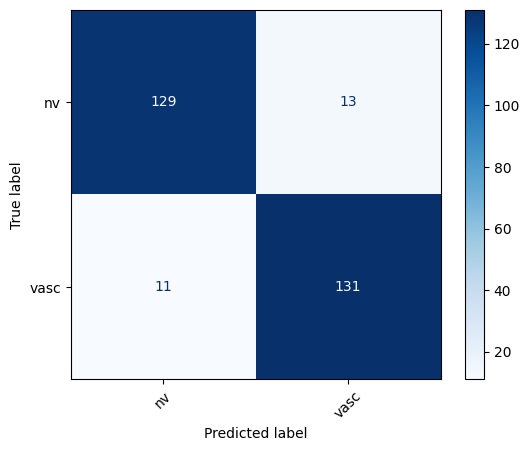

In [22]:
cv_classification_report(svm_grid_search, X_raw_flat, y_raw, cv=cv)

Checking the performance with `cross_val_predict` and `cross_val_score` from sklearn, we can see that the scores are noticeably worse than with `GridSearchCV`. This might indicate that `GridSearchCV` gives to optimistic results and can possibly generlize worse on unseen data. However, the scores are still pretty good, with around 0.92 macro recall score, which is still very strong baseline for the simple raw-pixel SVM.

## SVM model training with ray framework

Now we will utilize Ray framework for parallel feature extraction and model training, which should speed up the process and allow us to easily scale to larger datasets in the future.

In [ ]:
if ray.is_initialized():
    ray.shutdown()

# ray.init(address="local", object_store_memory=1.5 * 1024 * 1024 * 1024)
# ray_address = os.getenv("RAY_ADDRESS", "ray://localhost:10001").strip()
# ray_address = "ray://localhost:10001"
# ray_address = "auto"
ray_address = "local"
if ray_address.startswith("ray://"):
    print(f"Connecting to Ray cluster at {ray_address}...")
    ray.init(address=ray_address)
else:
    print("Initializing Ray locally...")
    ray.init(address="local", object_store_memory=1.5 * 1024 * 1024 * 1024)

Initializing Ray locally...


2026-06-01 11:42:09,853	INFO worker.py:2003 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
/home/wiktor/university/sem6/distributed_systems/skin_cancer/.venv/lib/python3.13/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [14]:
img_ds = ray.data.from_pandas(df[["path", "label_id"]])

In [13]:
img_ds_transformed = img_ds.map(
    lambda r: {
        "path": r["path"],
        "label_id": r["label_id"],
        "image": load_image_array(r["path"], size=BASELINE_IMG_SIZE),
    },
)


In [14]:
img_ds_transformed.show(5)

2026-06-01 10:06:51,419	INFO dataset.py:3818 -- Tip: Use `take_batch()` instead of `take() / show()` to return records in pandas or numpy batch format.
2026-06-01 10:06:51,458	INFO logging.py:416 -- Registered dataset logger for dataset dataset_2_0
2026-06-01 10:06:51,503	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_2_0. Full logs are in /tmp/ray/session_2026-06-01_10-06-36_314737_144369/logs/ray-data
2026-06-01 10:06:51,506	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_2_0: InputDataBuffer[Input] -> LimitOperator[limit=5] -> TaskPoolMapOperator[Map(<lambda>)]
2026-06-01 10:06:51,521	WARNING resource_manager.py:169 -- ⚠️  Ray's object store is configured to use only 32.3% of available memory (1.5GiB out of 4.6GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory. You can do this by setting the 'object_store_memory' parameter when calling ray.init() or by setting the RAY_DE

{'path': 'vascular_skin_lesion/nv/ISIC_0024384.jpg', 'label_id': 0, 'image': array([[[0.8509804 , 0.5019608 , 0.5254902 ],
        [0.8509804 , 0.5019608 , 0.5176471 ],
        [0.8509804 , 0.5019608 , 0.53333336],
        ...,
        [0.8039216 , 0.4745098 , 0.47058824],
        [0.78431374, 0.45490196, 0.45882353],
        [0.74509805, 0.43529412, 0.43137255]],

       [[0.827451  , 0.4862745 , 0.46666667],
        [0.8509804 , 0.5019608 , 0.5019608 ],
        [0.85490197, 0.5019608 , 0.5176471 ],
        ...,
        [0.8117647 , 0.47843137, 0.47843137],
        [0.80784315, 0.47843137, 0.48235294],
        [0.8156863 , 0.49019608, 0.49803922]],

       [[0.81960785, 0.4745098 , 0.46666667],
        [0.8156863 , 0.47843137, 0.45490196],
        [0.8509804 , 0.50980395, 0.50980395],
        ...,
        [0.8039216 , 0.4745098 , 0.47058824],
        [0.8117647 , 0.49019608, 0.49411765],
        [0.8117647 , 0.49019608, 0.49411765]],

       ...,

       [[0.77254903, 0.4627451 , 0.42

In [15]:
train_ds, test_ds = img_ds_transformed.train_test_split(test_size=0.2, stratify="label_id", seed=RANDOM_STATE)

train_df = train_ds.to_pandas()
test_df = test_ds.to_pandas()

X_ray_raw_train = np.stack(train_df["image"].values)
X_ray_raw_test = np.stack(test_df["image"].values)

y_ray_train = train_df["label_id"].astype(int).values
y_ray_test = test_df["label_id"].astype(int).values

X_ray_raw_train_flat = X_ray_raw_train.reshape((X_ray_raw_train.shape[0], -1))
X_ray_raw_test_flat = X_ray_raw_test.reshape((X_ray_raw_test.shape[0], -1))

y_ray_full = np.concatenate([y_ray_train, y_ray_test])
X_ray_raw_full_flat = np.concatenate([X_ray_raw_train_flat, X_ray_raw_test_flat], axis=0)

print("Split sizes:", X_ray_raw_train.shape[0], X_ray_raw_test.shape[0])


2026-06-01 10:06:52,902	INFO logging.py:416 -- Registered dataset logger for dataset dataset_5_0
2026-06-01 10:06:52,908	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_5_0. Full logs are in /tmp/ray/session_2026-06-01_10-06-36_314737_144369/logs/ray-data
2026-06-01 10:06:52,909	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_5_0: InputDataBuffer[Input] -> TaskPoolMapOperator[Map(<lambda>)] -> HashShuffleOperator[Shuffle(key_columns=('label_id',), num_partitions=200)] -> TaskPoolMapOperator[MapBatches(add_train_flag)]
2026-06-01 10:06:52,996	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_5_0 =======
2026-06-01 10:06:52,997	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-06-01 10:06:52,998	INFO logging_progress.py:227 -- Active & requested resources: 0.6/12 CPU, 0.0B/768.0MiB object store
2026-06-01 10:06:52,999	INFO logging_progress.py:181 -- 
2026-06-01 10:06:52,999	INFO logging_progress.py:231 -- Map(<lambda>): 0/

Split sizes: 228 56


## Ray training for simple SVM model

Let's train the same classifier using Ray Train. We will use the same hyperparameters as before (`kernel="rbf"`) to ensure a fair comparison.

In [16]:
from ray.util.joblib import register_ray

register_ray()

In [17]:
def cv_classification_report_ray(model, X, y, cv):
    with joblib.parallel_backend("ray"):
        preds = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    summarize_classification(y_true=y, y_pred=preds, labels=label_names)

Ray raw-pixel SVM report (test data):
              precision    recall  f1-score   support

          nv       0.92      0.79      0.85        28
        vasc       0.81      0.93      0.87        28

    accuracy                           0.86        56
   macro avg       0.86      0.86      0.86        56
weighted avg       0.86      0.86      0.86        56



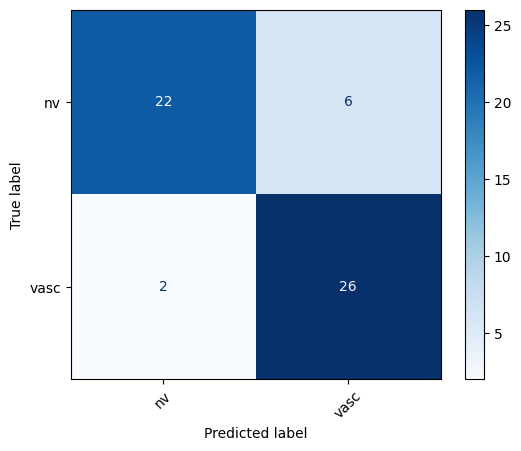

In [18]:
ray_simple_svm = SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE)
with joblib.parallel_backend("ray"):
    ray_simple_svm.fit(X_ray_raw_train_flat, y_ray_train)

print("Ray raw-pixel SVM report (test data):")
summarize_classification(y_true=y_ray_test, y_pred=ray_simple_svm.predict(X_ray_raw_test_flat), labels=label_names)

Ray raw-pixel SVM report (full dataset):
              precision    recall  f1-score   support

          nv       0.95      0.82      0.88       142
        vasc       0.84      0.96      0.90       142

    accuracy                           0.89       284
   macro avg       0.90      0.89      0.89       284
weighted avg       0.90      0.89      0.89       284



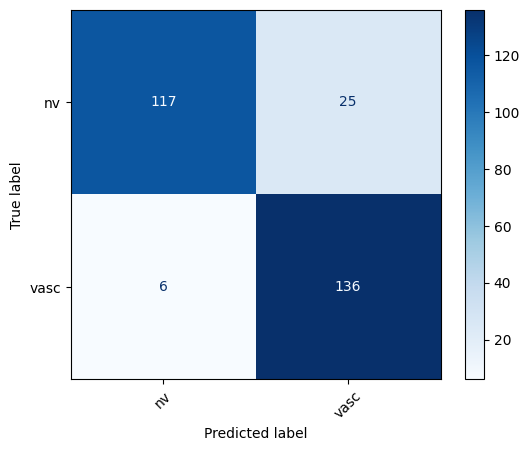

In [19]:
print("Ray raw-pixel SVM report (full dataset):")
summarize_classification(y_true=y_ray_full, y_pred=ray_simple_svm.predict(X_ray_raw_full_flat), labels=label_names)

In [22]:
ray_baseline_model = Pipeline(
    [
        ("scaler", SkMinMaxScaler(feature_range=(-1, 1))),
        ("svc", SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)

ray_svm_grid_search = GridSearchCV(
    estimator=ray_baseline_model,
    param_grid=simple_svm_grid_params,
    cv=cv,
    scoring="recall_macro",
    n_jobs=-1,
    error_score="raise",
)
with joblib.parallel_backend("ray"):
    ray_svm_grid_search.fit(X_ray_raw_train_flat, y_ray_train)

ray_simple_svm_best_model = ray_svm_grid_search.best_estimator_


2026-06-01 10:07:27,103	WARNING pool.py:599 -- The 'context' argument is not supported using ray. Please refer to the documentation for how to control ray initialization.


Ray raw-pixel GridSearch SVM report (test data):
              precision    recall  f1-score   support

          nv       0.93      0.89      0.91        28
        vasc       0.90      0.93      0.91        28

    accuracy                           0.91        56
   macro avg       0.91      0.91      0.91        56
weighted avg       0.91      0.91      0.91        56



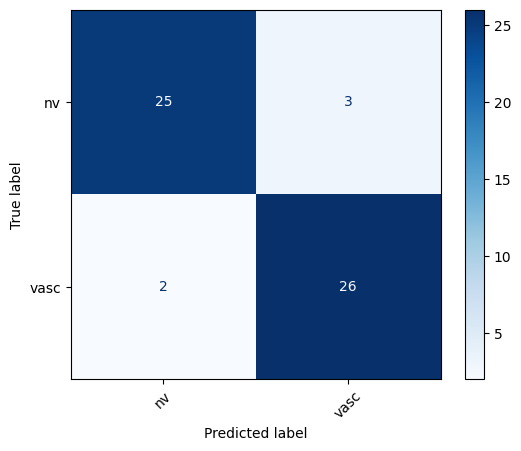

Ray raw-pixel GridSearch SVM report (full data):
              precision    recall  f1-score   support

          nv       0.99      0.98      0.98       142
        vasc       0.98      0.99      0.98       142

    accuracy                           0.98       284
   macro avg       0.98      0.98      0.98       284
weighted avg       0.98      0.98      0.98       284



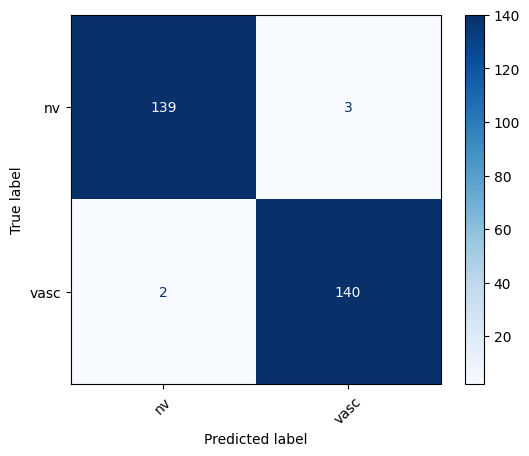

In [23]:

print("Ray raw-pixel GridSearch SVM report (test data):")
summarize_classification(y_true=y_ray_test, y_pred=ray_simple_svm_best_model.predict(X_ray_raw_test_flat), labels=label_names)

print("Ray raw-pixel GridSearch SVM report (full data):")
summarize_classification(y_true=y_ray_full, y_pred=ray_simple_svm_best_model.predict(X_ray_raw_full_flat), labels=label_names)

Ray raw-pixel CV report (test data):
              precision    recall  f1-score   support

          nv       0.67      0.71      0.69        28
        vasc       0.69      0.64      0.67        28

    accuracy                           0.68        56
   macro avg       0.68      0.68      0.68        56
weighted avg       0.68      0.68      0.68        56



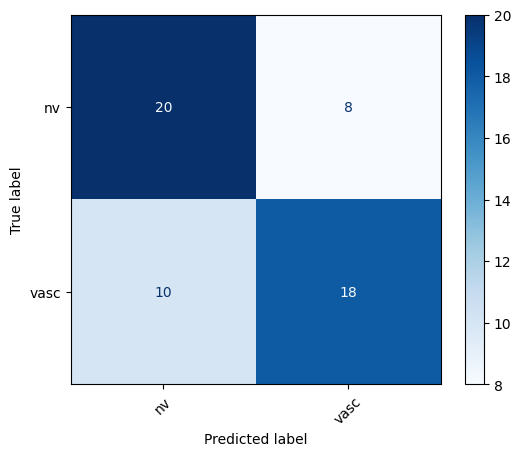

Ray raw-pixel CV report (full data):
              precision    recall  f1-score   support

          nv       0.90      0.93      0.91       142
        vasc       0.93      0.89      0.91       142

    accuracy                           0.91       284
   macro avg       0.91      0.91      0.91       284
weighted avg       0.91      0.91      0.91       284



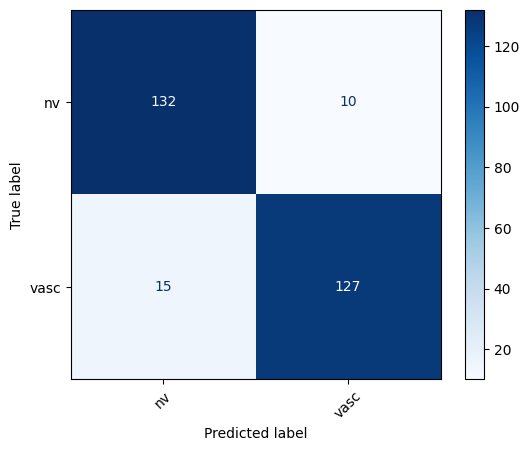

In [24]:
print("Ray raw-pixel CV report (test data):")
cv_classification_report_ray(ray_svm_grid_search, X_ray_raw_test_flat, y_ray_test, cv=cv)

print("Ray raw-pixel CV report (full data):")
cv_classification_report_ray(ray_svm_grid_search, X_ray_raw_full_flat, y_ray_full, cv=cv)

## Hyperparameter tuning with Ray Tune

Finally, we will use Ray Tune to perform hyperparameter tuning for the SVM model. We will search over a small grid of `C` and `kernel` values, and evaluate the performance with cross-validation.

In [25]:
def train_svm(config, X, y, seed):
    model = Pipeline(
        [
            ("scaler", SkMinMaxScaler(feature_range=(-1, 1))),
            (
                "svc",
                SVC(
                    kernel=config["kernel"],
                    C=config["C"],
                    gamma=config["gamma"],
                    class_weight="balanced",
                    random_state=seed
                    )
                ),
        ]
    )
    model.fit(X, y)
    return model

In [26]:
def train_svm_tune_ray(config, X, y, seed):
    model = train_svm(config, X, y, seed)
    model.fit(X, y)
    pred = model.predict(X)
    tune.report({"f1_macro": float(f1_score(y, pred, average="macro"))})


In [27]:
param_space = {
    "C": tune.grid_search([0.1, 1, 10, 100]),
    "gamma": tune.grid_search(["scale", 0.01, 0.1, 1.0]),
    "kernel": tune.grid_search(["rbf", "linear"]),
}

tuner = Tuner(
    tune.with_parameters(
        train_svm_tune_ray,
        X=X_ray_raw_train_flat,
        y=y_ray_train,
        seed=RANDOM_STATE,
    ),
    param_space=param_space,
    tune_config=TuneConfig(metric="f1_macro", mode="max"),
)

result_grid = tuner.fit()
best_result = result_grid.get_best_result()
best_config = best_result.config

2026-06-01 10:11:15,564	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/home/wiktor/ray_results/train_svm_tune_ray_2026-06-01_10-10-47' in 0.0238s.
2026-06-01 10:11:15,572	INFO tune.py:1033 -- Total run time: 27.69 seconds (27.50 seconds for the tuning loop).


In [28]:
best_config

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

In [29]:
svm_tunned_ray = train_svm(best_config, X_ray_raw_train_flat, y_ray_train, seed=RANDOM_STATE)

Ray raw-pixel report (full data):
              precision    recall  f1-score   support

          nv       0.99      0.98      0.98       142
        vasc       0.98      0.99      0.98       142

    accuracy                           0.98       284
   macro avg       0.98      0.98      0.98       284
weighted avg       0.98      0.98      0.98       284



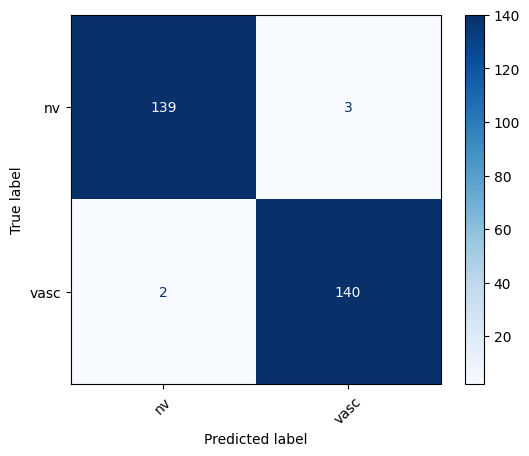

In [30]:
print("Ray raw-pixel report (full data):")
summarize_classification(y_true=y_ray_full, y_pred=svm_tunned_ray.predict(X_ray_raw_full_flat), labels=label_names)

Ray raw-pixel CV report (full data):
              precision    recall  f1-score   support

          nv       0.92      0.91      0.91       142
        vasc       0.91      0.92      0.92       142

    accuracy                           0.92       284
   macro avg       0.92      0.92      0.92       284
weighted avg       0.92      0.92      0.92       284



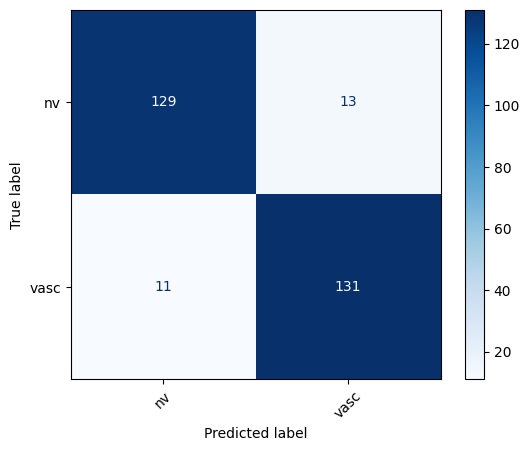

In [31]:
print("Ray raw-pixel CV report (full data):")
cv_classification_report_ray(svm_tunned_ray, X_ray_raw_full_flat, y_ray_full, cv=cv)

In [32]:
ray.shutdown()